# G01 — Analyse des Résultats du Random Search
**Projet** : Fine-tuning de Transformers  
**Groupe** : G01 | P01 Benchmark d'Optimiseurs | Random Search

⚠️ **Prérequis** : Exécuter `python main.py` avant d'utiliser ce notebook.

In [1]:
import sys
sys.path.insert(0, '..')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
print('Prêt ✓')

Prêt ✓


## 1. Chargement des résultats

In [2]:
results = pd.read_csv('../outputs/results/random_search_results.csv')
with open('../outputs/results/best_config.json') as f:
    best = json.load(f)

print(f'Configurations testées : {len(results)}')
print('\nAperçu :')
results.style.highlight_max(subset=['best_val_acc', 'test_accuracy', 'test_f1'],
                             color='#d4edda')

Configurations testées : 9

Aperçu :


,optimizer,learning_rate,run_idx,best_val_acc,best_val_f1,final_val_loss,test_accuracy,test_f1,total_time_s
0,AdamW,0.000015,1,0.882500,0.882335,0.370761,0.876000,0.875664,6281.571445
1,AdamW,0.000123,2,0.842500,0.842452,0.505230,0.824000,0.823772,4813.618312
2,AdamW,0.000208,3,0.815000,0.814981,0.599516,0.798000,0.797999,4672.698911
3,SGD,0.000001,1,0.497500,0.332220,0.697239,0.500000,0.336856,4580.097986
4,SGD,0.000001,2,0.497500,0.332220,0.697223,0.500000,0.336856,4613.961807
5,SGD,0.000058,3,0.570000,0.557203,0.690612,0.600000,0.588944,4658.547263
6,Adafactor,0.000002,1,0.830000,0.829962,0.394664,0.846000,0.845994,4771.113165
7,Adafactor,0.000005,2,0.862500,0.862355,0.347642,0.866000,0.865806,5417.681705
8,Adafactor,0.000012,3,0.877500,0.876760,0.389261,0.854000,0.852808,4968.440282


## 2. Tableau comparatif par optimiseur

In [3]:
summary = results.groupby('optimizer').agg(
    best_val_acc  = ('best_val_acc',   'max'),
    mean_val_acc  = ('best_val_acc',   'mean'),
    best_test_acc = ('test_accuracy',  'max'),
    best_f1       = ('test_f1',        'max'),
    mean_time_s   = ('total_time_s',   'mean'),
).round(4).reset_index()

print('Résumé par optimiseur :')
print(summary.to_string(index=False))

Résumé par optimiseur :
optimizer  best_val_acc  mean_val_acc  best_test_acc  best_f1  mean_time_s
Adafactor        0.8775        0.8567          0.866   0.8658    5052.4117
    AdamW        0.8825        0.8467          0.876   0.8757    5255.9629
      SGD        0.5700        0.5217          0.600   0.5889    4617.5357


## 3. Meilleure configuration

In [4]:
print('★ MEILLEURE CONFIGURATION')
print('─' * 40)
for k, v in best.items():
    if isinstance(v, float):
        print(f'  {k:20s} : {v:.4f}')
    else:
        print(f'  {k:20s} : {v}')

★ MEILLEURE CONFIGURATION
────────────────────────────────────────
  optimizer            : AdamW
  learning_rate        : 0.0000
  best_val_acc         : 0.8825
  test_accuracy        : 0.8760
  test_f1              : 0.8757


## 4. Visualisation : Val Accuracy par optimiseur × LR

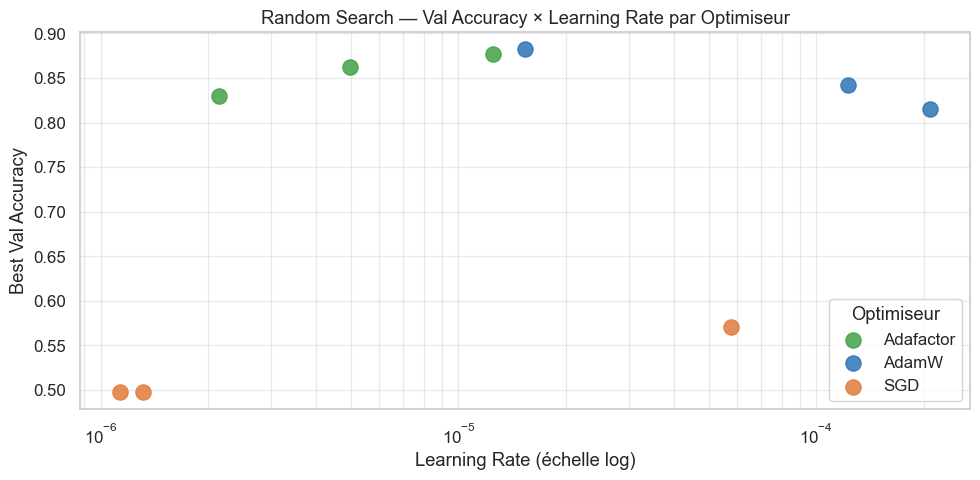

In [5]:
colors = {'AdamW': '#2E75B6', 'SGD': '#E07B39', 'Adafactor': '#43A047'}

fig, ax = plt.subplots(figsize=(10, 5))
for opt, grp in results.groupby('optimizer'):
    ax.scatter(grp['learning_rate'], grp['best_val_acc'],
               label=opt, color=colors.get(opt, '#888'),
               s=120, alpha=0.85, zorder=3)

ax.set_xscale('log')
ax.set_xlabel('Learning Rate (échelle log)')
ax.set_ylabel('Best Val Accuracy')
ax.set_title('Random Search — Val Accuracy × Learning Rate par Optimiseur')
ax.legend(title='Optimiseur')
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.show()

## 5. Métriques de platitude (Sharpness)

In [6]:
try:
    landscape = pd.read_csv('../outputs/results/landscape_metrics.csv')
    print('Sharpness par configuration :')
    print(landscape.sort_values('sharpness').to_string(index=False))
    print('\n→ Une sharpness plus basse indique un minimum plus plat,')
    print('  ce qui est associé à une meilleure généralisation (Keskar et al., 2017).')
except FileNotFoundError:
    print('Fichier landscape_metrics.csv non trouvé. Lancez main.py en premier.')

Sharpness par configuration :
              run_label  sharpness
      SGD | LR=5.76e-05   0.002095
Adafactor | LR=1.24e-05   0.132872
    AdamW | LR=1.53e-05   0.149704

→ Une sharpness plus basse indique un minimum plus plat,
  ce qui est associé à une meilleure généralisation (Keskar et al., 2017).


## 6. Conclusions préliminaires

In [7]:
best_opt = summary.loc[summary['best_val_acc'].idxmax(), 'optimizer']
fastest  = summary.loc[summary['mean_time_s'].idxmin(),  'optimizer']

print(f'✅ Optimiseur le plus performant (val) : {best_opt}')
print(f'⚡ Optimiseur le plus rapide           : {fastest}')
print()
print('Recommandation : Pour le fine-tuning de DistilBERT sur IMDb,')
print(f'  {best_opt} avec un LR autour de {best["learning_rate"]:.2e} semble optimal.')

✅ Optimiseur le plus performant (val) : AdamW
⚡ Optimiseur le plus rapide           : SGD

Recommandation : Pour le fine-tuning de DistilBERT sur IMDb,
  AdamW avec un LR autour de 1.53e-05 semble optimal.
